## **Libraries**

In [1]:
import sys
sys.path.append('../src')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import visualizations

---
## **EDA**
### **Data Loading**

- In this second notebook, we load the dataset transformed and cleaned in the 1st notebook.

In [2]:
path = "../datasets/df_clean.csv"

df = pd.read_csv(path)
display(df.head())

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancellation
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,0
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,0
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,0



### **Descriptive Statistics**
#### **Outliers & Distributions**

Next, the distributions of the only useful numerical columns, **Quantity** and **Price** will be displayed.

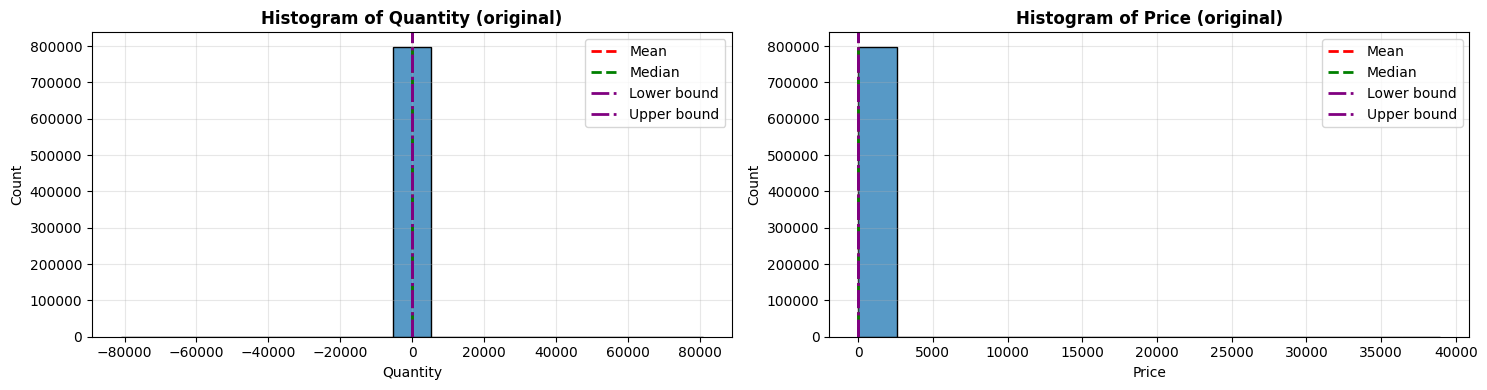

In [3]:
num_cols = ["Quantity", "Price"]
visualizations.distribution(df, num_cols)

As it can be seen, both distributions are heavily affected by extreme values, as no difference can be appreciated between the mean, meadian (Q2), and lower and upper bound of the IQR. Instead of removing the data outside the IQR boundaries, let's observe the distribution applyting a tranformation that allow us to visualize positive and non-positive values, since the logarithmic scaling doesn't work with non-positive values, and the `MinMaxScaler` and `StandardScaler` don't change the way the values are distributed.

The following transformation will be applied (only to visualize the data):
$$x_{transformed​}=sign(x)⋅log(1+∣x∣)$$

- **`sign(x)`** returns:
  - `+1` if \( x > 0 \), `0` if \( x = 0 \), `-1` if \( x < 0 \)

- **Why this form?**
  - Standard log cannot handle **negative values or zero**
  - \( \log(1 + |x|) \) ensures all inputs are valid and reduces skewness
  - `sign(x)` restores the original positive/negative direction

- **What problem does it solve?**
  - Allows transforming data with **negatives and zeros**
  - Keeps the distribution shape interpretable for visualization

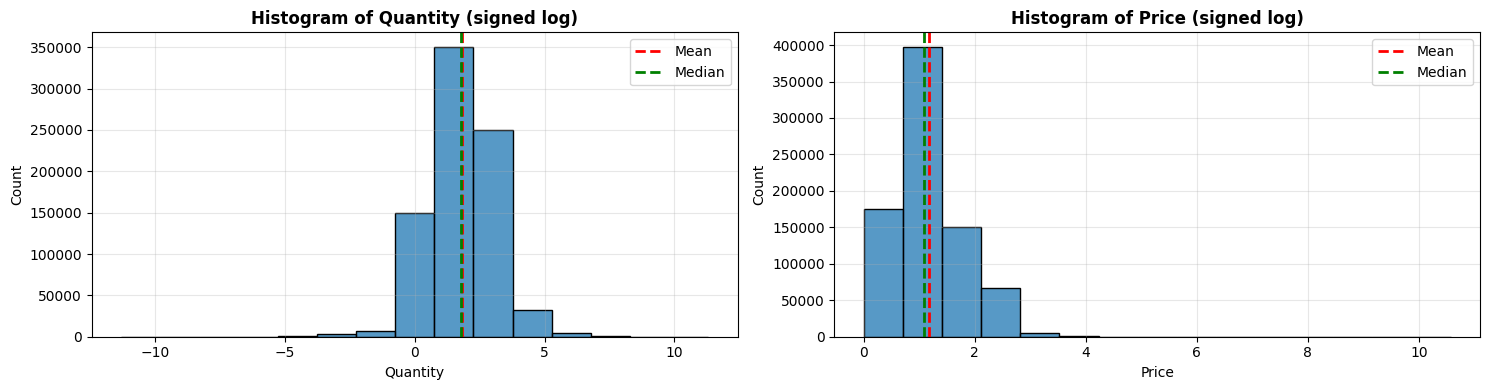

In [4]:
visualizations.distribution(df, num_cols, scale=True)

With the data scaled, both distributions can be easily observed. If the IQR process would have been applied to treat the outliers, we would had lost a large portion of the dataset (and not necesarily outliers). For future steps involving predictive modelling with machine learning algorithms, we must recall that the data must be scaled before training the models.

---
### **Visualizations**

Before proceeding with the visualizations, some feature engineering will be done.

In [5]:
# Time features Year, Month, Quarter and Weekday
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Quarter"] = df["InvoiceDate"].dt.quarter
df["Weekday"] = df["InvoiceDate"].dt.day_name()

# Total price of the product quantity x price
df["TotalPrice"] = df["Quantity"] * df["Price"]

**Country**

c:\Users\HP\Desktop\Master\6. ML_DL\ML_Project\notebooks\../src\visualizations.py:197: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,1].set_xticklabels([f"{x*100:.1f}%" for x in axes[0,1].get_xticks()])


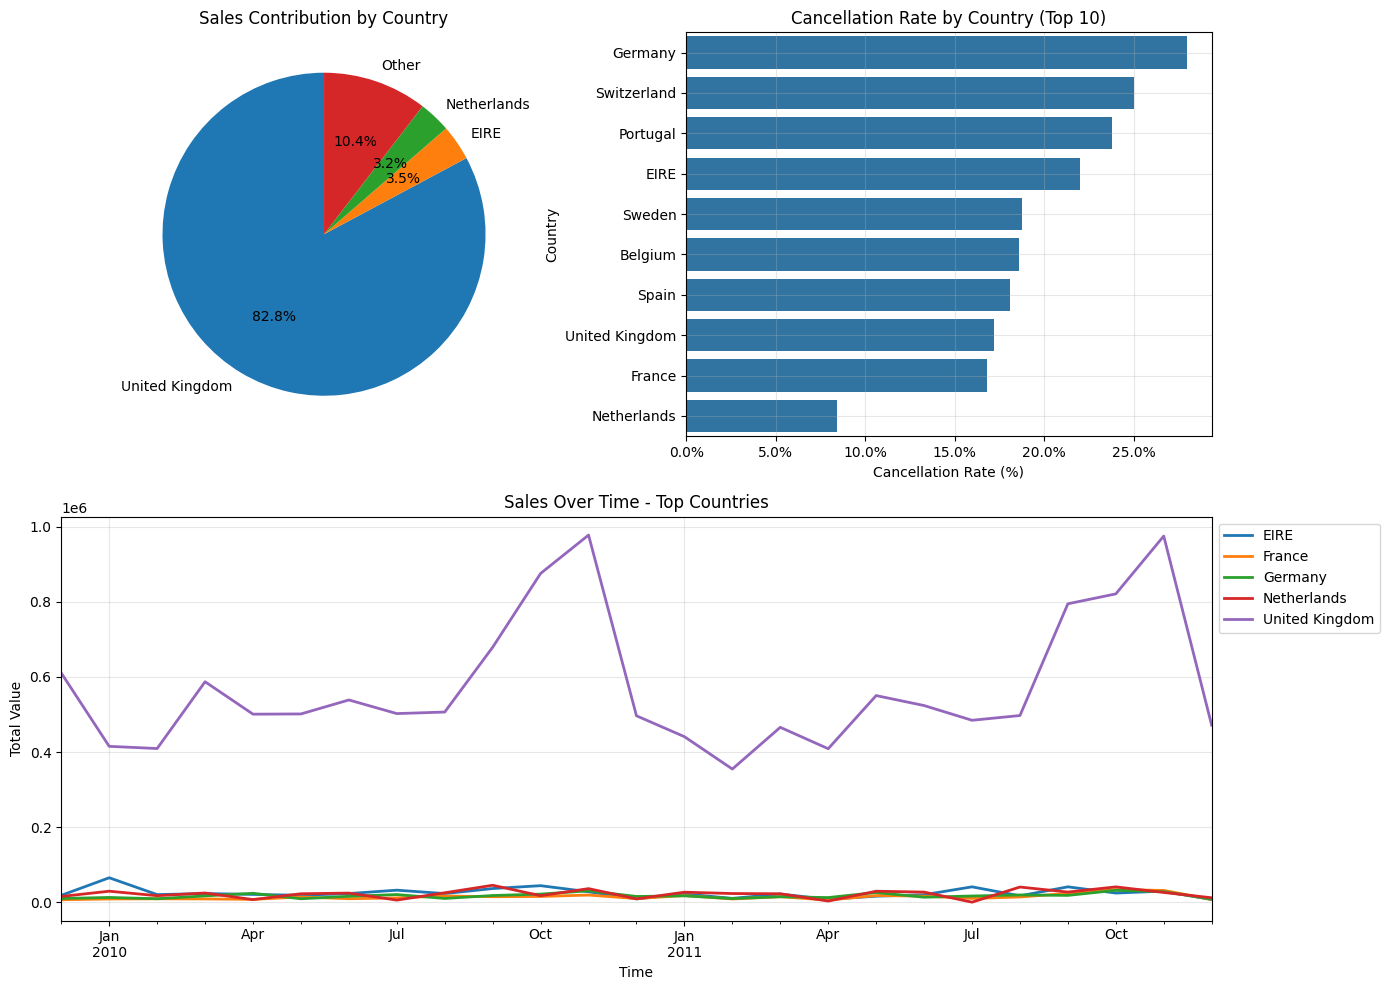

In [6]:
visualizations.country(df)

From both, the piechart and the lineplot, can be derived that the customers in the United Kingdom (same country our company is located in) are almost the totally of the income, with a 82.8% of total sales contribution. Related to this matter, the lineplot gives us more information realted with the seasonality of the sales, highlighting the increase of sales from August to Novemberi both 2010 and 2011.

From the sidebar chart, are displayed the countries that have a higher rate of cancellations with respect to their number of unique invoices.

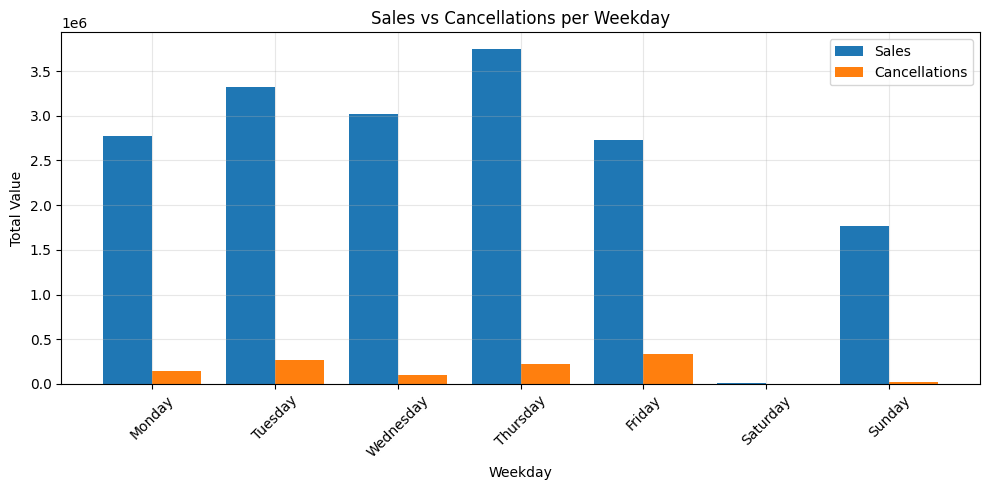

In [7]:
visualizations.weekday(df)

Since a montlhy seasonality has been spotted in the previous visualization, here we can see if there's any pattern in sales/cancellations with respect the weekday. Despite the decrease in sales and cancellations at the weekend, no other significant pattern can be derived.

**Sales per Product**

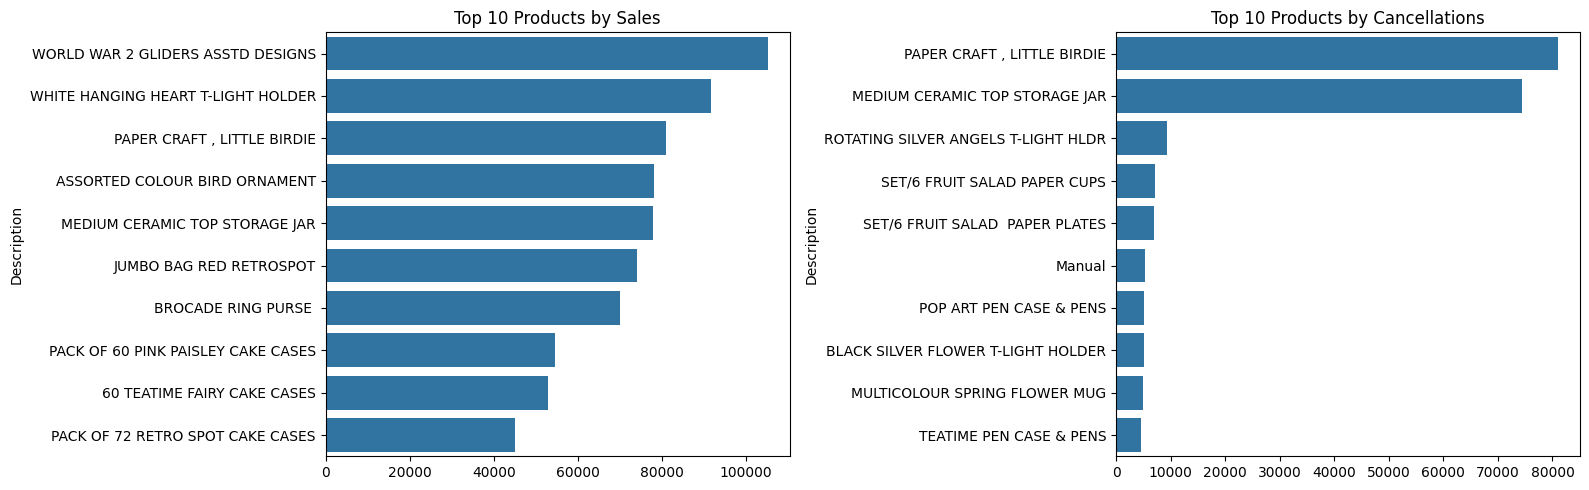

In [8]:
# Aggregate
product_sales = df[df["Quantity"] > 0].groupby("Description")["Quantity"].sum().sort_values(ascending=False)
product_cancellations = df[df["Quantity"] < 0].groupby("Description")["Quantity"].sum().abs().sort_values(ascending=False)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=product_sales.values[:10], y=product_sales.index[:10], ax=axes[0])
axes[0].set_title("Top 10 Products by Sales")

sns.barplot(x=product_cancellations.values[:10], y=product_cancellations.index[:10], ax=axes[1])
axes[1].set_title("Top 10 Products by Cancellations")

plt.tight_layout()
plt.show()

#### **Customer Analysis**

In [9]:
customer_df = df[df["Cancellation"] == 0].groupby("Customer ID").agg({
    "Invoice": "nunique",          # number of orders
    "Quantity": "sum",               # total items bought
    "TotalPrice": "sum",             # total money spent
    "InvoiceDate": ["min", "max"]    # first & last purchase
})

# Flatten columns
customer_df.columns = ["NumOrders", "TotalQuantity", "TotalSpent", "FirstPurchase", "LastPurchase"]

customer_df.head()

,NumOrders,TotalQuantity,TotalSpent,FirstPurchase,LastPurchase
Customer ID,,,,,
12346,12,74285,77556.46,2009-12-14 08:34:00,2011-01-18 10:01:00
12347,8,2967,4921.53,2010-10-31 14:20:00,2011-12-07 15:52:00
12348,5,2714,2019.40,2010-09-27 14:59:00,2011-09-25 13:13:00
12349,4,1624,4428.69,2010-04-29 13:20:00,2011-11-21 09:51:00
12350,1,197,334.40,2011-02-02 16:01:00,2011-02-02 16:01:00


C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


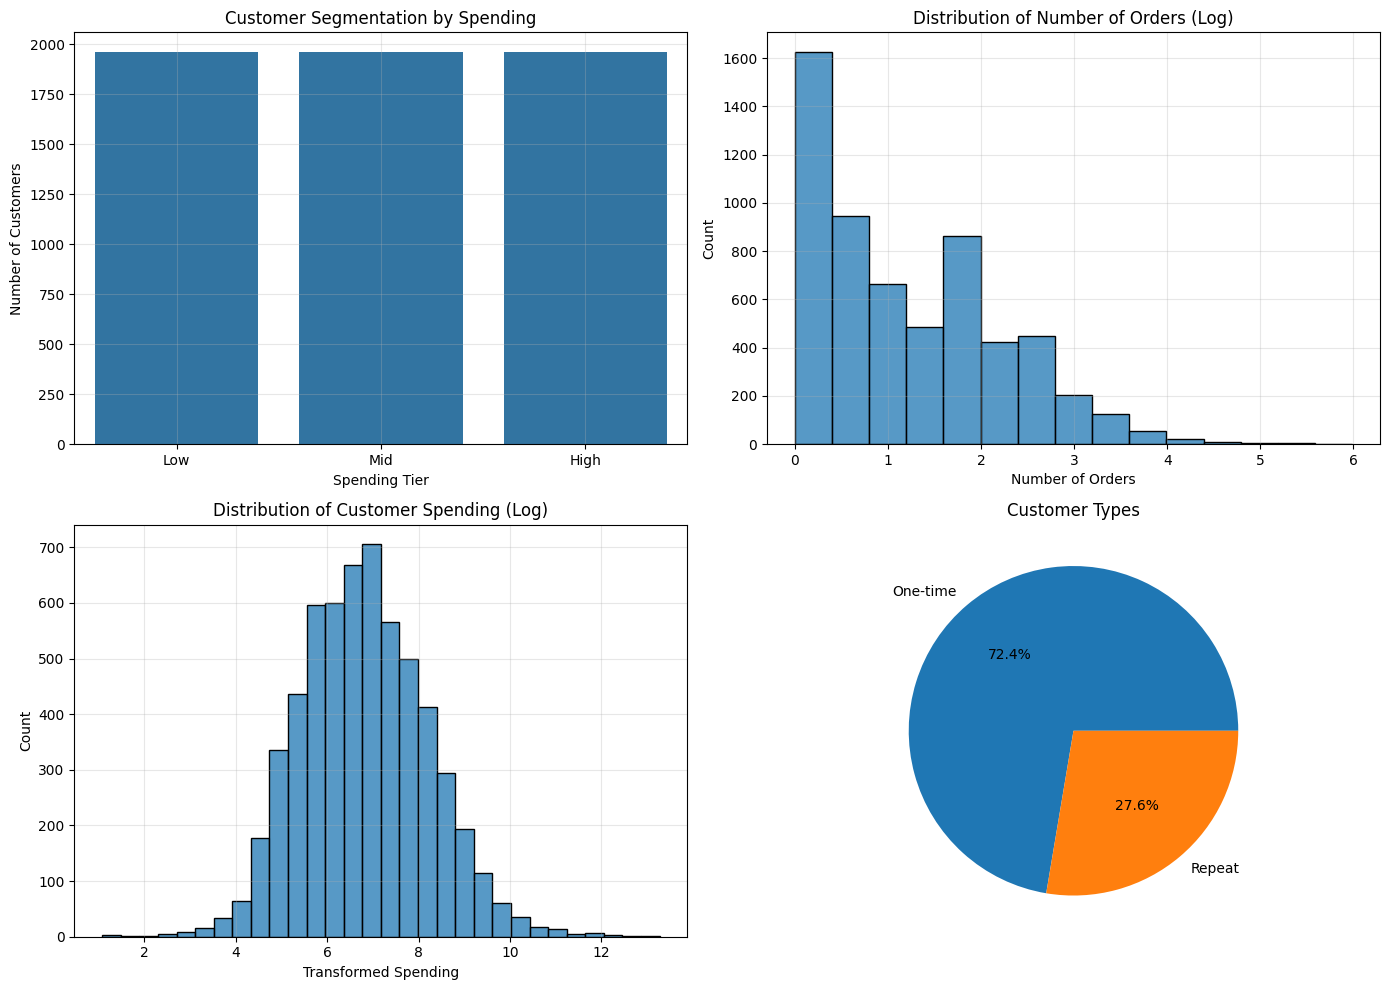

In [10]:
visualizations.customer(customer_df)

**Customer segmentation by spending (BarChart)**
- Looks like there's exactly the same amount of Low/Mid and High spending tier customers. Suggesting this company gets its a high portion of their revenue to the group of high tier spending customers.

**Distribution of Number of Orders (Log)**
- The distribution has been logarithmic scaled for better visualization. The Log of this distribution follows an exponential-like distribution, so the real distribution follows the same behaviour but with a more agressive slope.

**Distribution of Customers Spending (Log)**
- Like the previous one, this distribution has been scaled with the logarithm. Here the distribution resembles to a normal with positive kurtosis (higher peak and fatter tails). For the real distribution we would see only 2-4 bins located at the center while little representation for the larger values in absolute value (large positive and large negative).

**Customer Types (PieChart)**
- From all the customers, only a 27.6% has ordered more than one invoice.

In [11]:
df.to_csv("../datasets/df_after_eda.csv", index=False)